
文件: baseline_results_newprompt_newrule
总样本数: 5000
Level      总数       正确数        正确率            
Level 1    437      67             15.33%
Level 2    894      90             10.07%
Level 3    1131     62              5.48%
Level 4    1214     33              2.72%
Level 5    1324     14              1.06%

文件: sft_lora_result
总样本数: 5000
Level      总数       正确数        正确率            
Level 1    437      281            64.30%
Level 2    894      406            45.41%
Level 3    1131     382            33.78%
Level 4    1214     259            21.33%
Level 5    1324     111             8.38%

文件: grpo_step_500_result
总样本数: 5000
Level      总数       正确数        正确率            
Level 1    437      343            78.49%
Level 2    894      568            63.53%
Level 3    1131     614            54.29%
Level 4    1214     476            39.21%
Level 5    1324     263            19.86%

文件: grpo_step_1000_result
总样本数: 5000
Level      总数       正确数        正确率            
Level 1    437      360 

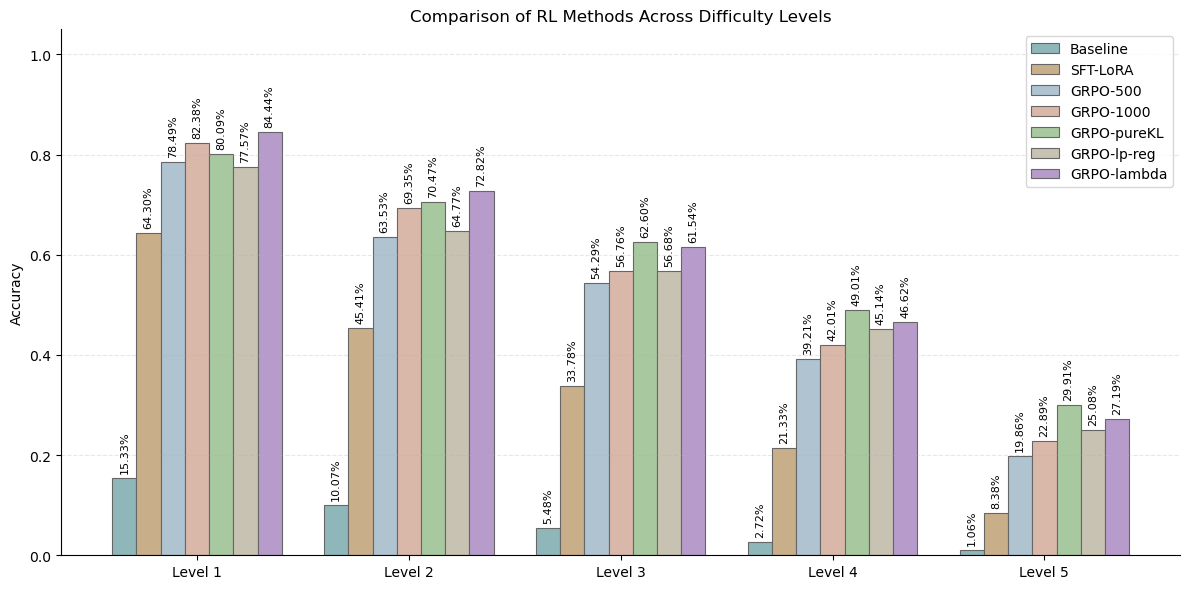


图像已保存到: all_methods_level_accuracy.png


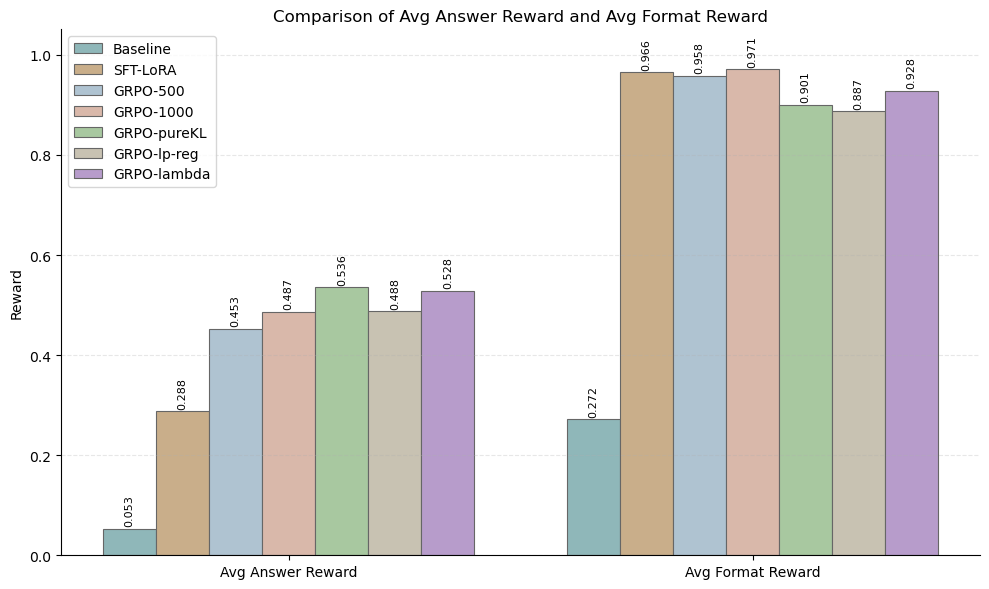


图像已保存到: all_methods_avg_rewards.png


In [15]:
import json
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


def load_items_from_json(json_path):
    """
    读取 json 文件中的 results 字段，并统一转成 list[dict]
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    results = data["results"]

    if isinstance(results, dict):
        items = list(results.values())
    elif isinstance(results, list):
        items = results
    else:
        raise TypeError(f"{json_path} 的 results 类型未知: {type(results)}")

    return items


def is_reward_correct(reward, tol=1e-8):
    """
    判断 reward 是否可视为正确（1 或 1.0）
    """
    if reward is None:
        return False
    try:
        return abs(float(reward) - 1.0) < tol
    except Exception:
        return False


def analyze_level_accuracy(json_path, level_order=None):
    """
    统计单个 json 文件在各个 level 上的正确率
    """
    if level_order is None:
        level_order = ["Level 1", "Level 2", "Level 3", "Level 4", "Level 5"]

    items = load_items_from_json(json_path)

    level_total = Counter()
    level_correct = Counter()

    for x in items:
        level = x.get("level", "Unknown")
        reward = x.get("reward", None)

        level_total[level] += 1
        if is_reward_correct(reward):
            level_correct[level] += 1

    extra_levels = sorted([lvl for lvl in level_total if lvl not in level_order])
    all_levels = level_order + extra_levels

    accuracy = {}
    for lvl in all_levels:
        total = level_total.get(lvl, 0)
        correct = level_correct.get(lvl, 0)
        accuracy[lvl] = correct / total if total > 0 else 0.0

    return {
        "name": Path(json_path).stem,
        "total": level_total,
        "correct": level_correct,
        "accuracy": accuracy,
        "all_levels": all_levels,
        "num_items": len(items),
    }


def print_analysis(result, level_order=None):
    """
    打印单个模型/算法的 level 统计结果
    """
    if level_order is None:
        level_order = ["Level 1", "Level 2", "Level 3", "Level 4", "Level 5"]

    all_levels = result["all_levels"]

    print(f"\n文件: {result['name']}")
    print(f"总样本数: {result['num_items']}")
    print("=" * 80)
    print(f"{'Level':<10} {'总数':<8} {'正确数':<10} {'正确率':<15}")
    print("=" * 80)

    for lvl in all_levels:
        total = result["total"].get(lvl, 0)
        correct = result["correct"].get(lvl, 0)
        acc = result["accuracy"].get(lvl, 0.0)
        print(f"{lvl:<10} {total:<8} {correct:<10} {acc:>10.2%}")


def plot_grouped_level_accuracy(
    json_paths,
    save_path="level_accuracy_bar.png",
    title="Accuracy by Difficulty Level",
    level_order=None,
    algo_names=None,
    figsize=(12, 6),
    dpi=150,
    show_value=True,
):
    """
    将多个 json 文件的各 level 正确率画到同一张分组柱状图中
    """
    if level_order is None:
        level_order = ["Level 1", "Level 2", "Level 3", "Level 4", "Level 5"]

    if not json_paths:
        raise ValueError("json_paths 不能为空")

    analyses = [analyze_level_accuracy(p, level_order=level_order) for p in json_paths]

    for res in analyses:
        print_analysis(res, level_order=level_order)

    if algo_names is None:
        algo_names = [res["name"] for res in analyses]

    if len(algo_names) != len(analyses):
        raise ValueError("algo_names 的长度必须和 json_paths 一致")

    all_found_levels = set()
    for res in analyses:
        all_found_levels.update(res["all_levels"])

    extra_levels = sorted([lvl for lvl in all_found_levels if lvl not in level_order])
    final_levels = level_order + extra_levels

    accuracy_matrix = []
    for res in analyses:
        row = [res["accuracy"].get(lvl, 0.0) for lvl in final_levels]
        accuracy_matrix.append(row)

    accuracy_matrix = np.array(accuracy_matrix)

    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=figsize)

    num_algos = len(analyses)
    num_levels = len(final_levels)

    x = np.arange(num_levels)

    total_width = 0.8
    bar_width = total_width / num_algos

    # 沿用你原来的配色
    soft_colors = [
        "#8FB7B9",  # 灰青
        "#C9AE8A",  # 卡其
        "#AFC3D1",  # 雾蓝
        "#D9B8AA",  # 豆沙
        "#A8C8A0",  # 鼠尾草绿
        "#C8C2B2",  # 灰米
        "#B79CCB",  # 淡紫
        "#9FB8B1",  # 青灰
    ]

    for i in range(num_algos):
        offsets = x - total_width / 2 + (i + 0.5) * bar_width
        color = soft_colors[i % len(soft_colors)]
        bars = ax.bar(
            offsets,
            accuracy_matrix[i],
            width=bar_width,
            label=algo_names[i],
            color=color,
            edgecolor="#666666",
            linewidth=0.8,
        )

        if show_value:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.01,
                    f"{h:.2%}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(final_levels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"\n图像已保存到: {save_path}")


# =========================
# 新增：统计平均 reward
# =========================
def analyze_avg_rewards(json_path):
    """
    从单个 json 文件中提取 avg_answer_reward 和 avg_format_reward

    优先从顶层字段读取；
    如果没有，再尝试从 summary / metrics 中读取。
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    avg_answer_reward = None
    avg_format_reward = None

    # 1. 顶层直接取
    avg_answer_reward = data.get("avg_answer_reward", None)
    avg_format_reward = data.get("avg_format_reward", None)

    # 2. 尝试 summary
    if avg_answer_reward is None and isinstance(data.get("summary"), dict):
        avg_answer_reward = data["summary"].get("avg_answer_reward", None)
    if avg_format_reward is None and isinstance(data.get("summary"), dict):
        avg_format_reward = data["summary"].get("avg_format_reward", None)

    # 3. 尝试 metrics
    if avg_answer_reward is None and isinstance(data.get("metrics"), dict):
        avg_answer_reward = data["metrics"].get("avg_answer_reward", None)
    if avg_format_reward is None and isinstance(data.get("metrics"), dict):
        avg_format_reward = data["metrics"].get("avg_format_reward", None)

    # 4. 如果还是没有，就报错，方便你定位 json 结构
    if avg_answer_reward is None or avg_format_reward is None:
        raise KeyError(
            f"{json_path} 中未找到 avg_answer_reward 或 avg_format_reward，"
            f"请先打印 JSON 顶层键确认结构。"
        )

    return {
        "name": Path(json_path).stem,
        "avg_answer_reward": float(avg_answer_reward),
        "avg_format_reward": float(avg_format_reward),
    }


def plot_avg_rewards_grouped(
    json_paths,
    save_path="avg_rewards_bar.png",
    title="Average Reward Comparison",
    algo_names=None,
    figsize=(10, 6),
    dpi=150,
    show_value=True,
):
    """
    画 avg_answer_reward 和 avg_format_reward 的分组柱状图：
    每种 reward 为一组，每组里放不同方法
    """
    if not json_paths:
        raise ValueError("json_paths 不能为空")

    analyses = [analyze_avg_rewards(p) for p in json_paths]

    if algo_names is None:
        algo_names = [res["name"] for res in analyses]

    if len(algo_names) != len(analyses):
        raise ValueError("algo_names 的长度必须和 json_paths 一致")

    reward_types = ["avg_answer_reward", "avg_format_reward"]
    x_labels = ["Avg Answer Reward", "Avg Format Reward"]

    reward_matrix = []
    for res in analyses:
        reward_matrix.append([
            res["avg_answer_reward"],
            res["avg_format_reward"],
        ])

    reward_matrix = np.array(reward_matrix)   # shape: (num_algos, 2)

    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=figsize)

    num_algos = len(analyses)
    num_groups = len(reward_types)

    x = np.arange(num_groups)

    total_width = 0.8
    bar_width = total_width / num_algos

    # 沿用你原来的配色
    soft_colors = [
        "#8FB7B9",  # 灰青
        "#C9AE8A",  # 卡其
        "#AFC3D1",  # 雾蓝
        "#D9B8AA",  # 豆沙
        "#A8C8A0",  # 鼠尾草绿
        "#C8C2B2",  # 灰米
        "#B79CCB",  # 淡紫
        "#9FB8B1",  # 青灰
    ]

    for i in range(num_algos):
        offsets = x - total_width / 2 + (i + 0.5) * bar_width
        color = soft_colors[i % len(soft_colors)]

        bars = ax.bar(
            offsets,
            reward_matrix[i],
            width=bar_width,
            label=algo_names[i],
            color=color,
            edgecolor="#666666",
            linewidth=0.8,
        )

        if show_value:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.005,
                    f"{h:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Reward")
    ax.set_title(title)

    ymax = max(1.05, float(np.max(reward_matrix)) + 0.08)
    ax.set_ylim(0, ymax)

    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"\n图像已保存到: {save_path}")


if __name__ == "__main__":
    json_paths = [
        r"/home/u2022310886/jupyterlab/RL/baseline_local/result_baseline/baseline_results_newprompt_newrule.json",
        r"/home/u2022310886/jupyterlab/RL/SFT/result_sft_lora/sft_lora_result.json",
        r"/home/u2022310886/jupyterlab/RL/GRPO/result_fullgrpo/grpo_step_500_result.json",
        r"/home/u2022310886/jupyterlab/RL/GRPO/result_fullgrpo_step_1000/grpo_step_1000_result.json",
        r"/home/u2022310886/jupyterlab/RL/GRPO/result_fullgrpo-oldclip-pureKL/grpo-pureKL_result.json",
        r"/home/u2022310886/jupyterlab/RL/GRPO/result_fullgrpo-oldclip-KL0.05/grpo-lp-reg_result.json",
        r"/home/u2022310886/jupyterlab/RL/GRPO/result_grpo_lambda_noadvclip/grpo-lambda_result.json",
    ]

    algo_names = [
        "Baseline",
        "SFT-LoRA",
        "GRPO-500",
        "GRPO-1000",
        "GRPO-pureKL",
        "GRPO-lp-reg",
        "GRPO-lambda",
    ]

    # 原图：各难度正确率
    plot_grouped_level_accuracy(
        json_paths=json_paths,
        save_path="all_methods_level_accuracy.png",
        title="Comparison of RL Methods Across Difficulty Levels",
        algo_names=algo_names,
    )

    # 新图：avg_answer_reward 和 avg_format_reward
    plot_avg_rewards_grouped(
        json_paths=json_paths,
        save_path="all_methods_avg_rewards.png",
        title="Comparison of Avg Answer Reward and Avg Format Reward",
        algo_names=algo_names,
    )